In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# Input
def client_input():
    '''
    purpose: function that gathers input when needed
    parameters: None
    return: ticker_symbol (str) - used to scrape information. 
            period (str) - used to gather time period of information.
    '''
    ticker_symbol = input("Enter ticker symbol: ").upper()
    period = input("Enter period (e.g. 2y, 1y, 6mo, 3mo, 1mo): ")

    return ticker_symbol, period

In [20]:
# Pull data
def pull_data(ticker_symbol, period):
    '''
    purpose: get raw historical price data from one ticker from yfinance
    parameter: ticker_symbol (str) - e.g. "AAPL". period (str) - e.g. "2y".
    return: hist (DataFrame) - daily price data, indexed by date. 
    '''
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period = period)
    hist = hist.dropna(subset = ['Close'])

    return hist

In [21]:
# Indicators
def calculate_indicators(hist):
    '''
    purpose: add moving average (MA) columns to the price data.
    parameters: hist (DataFrame) - must contain a 'Close' column.
    return: hist (DataFrame) - same data, with MA50 and MA200 columns added. 
    '''
    # Calculate MA50 & MA200
    hist['MA50'] = hist['Close'].rolling(50).mean()
    hist['MA200'] = hist['Close'].rolling(200).mean()

    # Calculate Relative-Strength Index (RSI)
    delta = hist['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = delta.where(delta < 0, 0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    hist['RSI'] = 100 - (100 / (1+rs))

    return hist

In [22]:
# Signals 
def generate_signals(hist):
    '''
    purpose: decide which days count as buy or sell, based on indicators.
    parameters: hist (DataFrame) 
    return: hist (DataFrame) - same data, with buy_signal and sell_signal columns added. 
    '''
    # MA Signal
    hist['buy_signal'] = (hist['MA50'] > hist['MA200']) & (hist['MA50'].shift(1) <= hist['MA200'].shift(1))
    hist['sell_signal'] = (hist['MA50'] < hist['MA200']) & (hist['MA50'].shift(1) >= hist['MA200'].shift(1))

    # RSI Signal
    oversold = hist['RSI'] <= 30
    overbought = hist['RSI'] >= 70

    return hist

In [23]:
# Backtest
def run_backtest(hist, initial_cash = 1000):
    '''
    purpose: walk through data day by day, simulating buys and sells.
    parameters: hist(DataFrame) - must contain buy_signal and sell_signal columns. 
                initial_cash(float) - starting cash.
    return: cash(float), shares(float), book_value(float) - ending state after the full simulation.
    '''
    cash = initial_cash
    shares = 0
    book_value = 0

    for date, row in hist.iterrows():
        price = row['Close']

        if row['buy_signal'] and cash >= price:
            spend = price
            shares_bought = spend / price
            shares += shares_bought
            cash -= spend
            book_value += spend
            print("\n", date, "BUY", round(shares, 2), "shares @", "$",round(price, 2))

        elif row['sell_signal'] and shares > 0:
            proceeds = shares * price
            realized_value = proceeds - book_value
            cash += proceeds
            shares = 0
            book_value = 0
            print("\n", date, "SELL", round(shares_bought, 2), "shares @", "$", round(price, 2), "Realized gain/loss:", round(realized_value, 2))

    return cash, shares, book_value

In [ ]:
def plot_ticker(hist, ticker_symbol):
    '''
    purpose: plot the closing price, MAs, and buy/sell signals for a given ticker.
    parameters: hist (DataFrame) - must contain Close, MA50, MA200, buy_signal, and sell_signal columns. 
                ticker_symbol (str) - used for chart title.
    return: None
    '''
    plt.figure(figsize = (12, 6))
    plt.plot(hist.index, hist['Close'], label = 'Close', alpha = 0.7)
    plt.plot(hist.index, hist['MA50'], label = 'MA50', color = "green")
    plt.plot(hist.index, hist['MA200'], label = 'MA200', color = "red")

    buys = hist[hist['buy_signal']]
    sells = hist[hist['sell_signal']]

    plt.scatter(buys.index, buys['Close'], 
                color = 'green', marker = '^', s = 100, label = 'Buy', zorder = 5)
    plt.scatter(sells.index, sells['Close'], 
                color = 'red', marker = 'v', s = 100, label = 'Sell', zorder = 5)
    
    plt.title({ticker_symbol})
    plt.legend()
    plt.show()

In [25]:
# Summarize Results
def summarize_results(hist, cash, shares, book_value, initial_cash):
    '''
    purpose: turn ending cash/shares/book_value into readable results.
    parameters: hist(DataFrame), cash(float), shares(float), book_value(float), initial_cash(float)
    return: None - this function only prints
    '''
    final_price = hist['Close'].iloc[-1]
    current_value_of_holdings = shares * final_price
    portfolio_value = cash + current_value_of_holdings
    overall_return = (portfolio_value - initial_cash) / initial_cash

    print("\n--- Summary ---")
    print(f"Available cash: ${cash:,.2f}")
    print(f"Current value of holdings: ${current_value_of_holdings:,.2f}")

    if shares > 0:
        holding_return = (current_value_of_holdings - book_value) / book_value
        holding_gain_loss = current_value_of_holdings - book_value

        print(f"Book Value (cost basis) of holdings: ${book_value:,.2f}")
        print(f"Return on holdings: {holding_return:.2%}")
        print(f"Gain/loss on holdings: ${holding_gain_loss:,.2f}")

    print(f"Total portfolio value: ${portfolio_value:,.2f}")
    print(f"Overall return (start to end): {overall_return:.2%}")


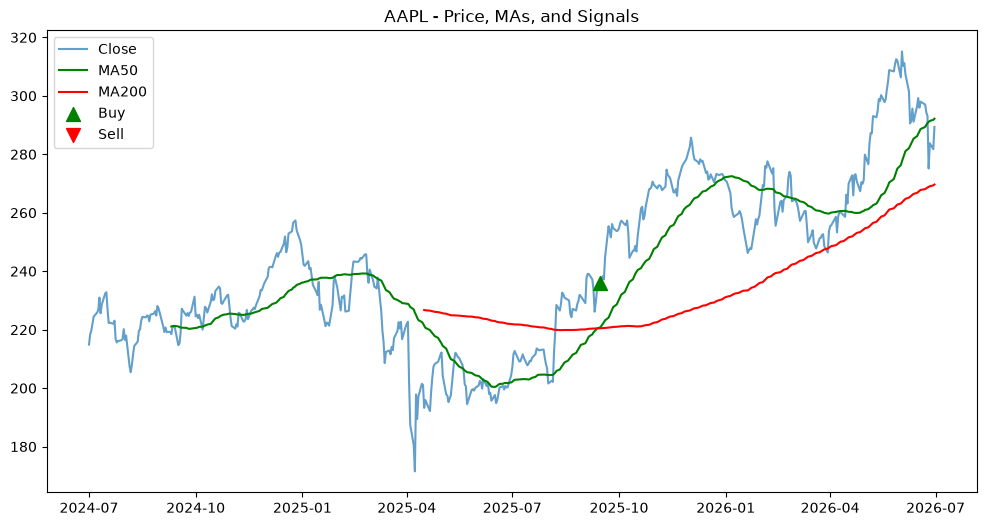


 2025-09-15 00:00:00-04:00 BUY 1.0 shares @ $ 236.03

--- Summary ---
Available cash: $763.97
Current value of holdings: $289.36
Book Value (cost basis) of holdings: $236.03
Return on holdings: 22.59%
Gain/loss on holdings: $53.33
Total portfolio value: $1,053.33
Overall return (start to end): 5.33%


In [26]:
# Main function
def run_engine():
    '''
    purpose: call the helper functions to run the backtest engine.
    parameters: None
    return: None - this function only prints
    '''
    ticker_symbol, period = client_input()
    hist = pull_data(ticker_symbol, period)
    hist = calculate_indicators(hist)
    hist = generate_signals(hist)
    plot_ticker(hist, ticker_symbol)
    cash, shares, book_value = run_backtest(hist)
    summarize_results(hist, cash, shares, book_value, initial_cash = 1000)

# actually runs the main function
run_engine()